## KDA Adapter - Electric Potential

Importing necessary packages:

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import os
import sys 
import networkx as nx
from sympy import symbols, latex, exp, Add, Mul
from kda import graph_utils, calculations, plotting, diagrams, expressions, ode

Graphing stuff

In [2]:
NL = np.array([
    [0, 1, 0, 1],
    [1, 0, 1, 0],
    [0, 1, 0, 1],
    [1, 0, 1, 0]
])

G = nx.MultiDiGraph()
graph_utils.generate_edges(G, NL)
pos = { 0: [1, 1],
1: [-1, 1],
2: [-1, -1],
3: [1, -1]
}


Figure Saving Function:

In [3]:
def save_figure(fig, filename):
    cwd = os.getcwd()
    for _ext in ("png", "svg", "pdf"):
        path = os.path.join(cwd, f"{filename}.{_ext}")
        fig.savefig(path, dpi=300)

define cycles and orders (hint: there's one order)

In [4]:
G_cycle = graph_utils.find_all_unique_cycles(G)[0]
G_order = [0, 1]

Making Variables, Sympy Expressions, Constants, etc.

In [5]:
#Making symbols for constants, variables, sympy expressions
z, qe, V, alpha, k, T = symbols(
    "z, qe, V, alpha, k, T"
)       

# Driving Force Variables
R_int, R_ext, R_on, R_off = symbols(
    "R_int, R_ext, R_on, R_off"
)

#Independent Variable: Gamma - Potential Distribution across States
gamma = symbols(
    "gamma"
)

# Second Tier Constants
beta, epsilon1, epsilon2, delta1, delta2 = symbols(
    "beta, epsilon1, epsilon2, delta1, delta2")

# Net rate labels
k12, k21, k23, k32, k34, k43, k41, k14 = symbols(
    "k12, k21, k23, k32, k34, k43, k41, k14")

# Bare rates:
k23b, k32b, k14b, k41b = symbols(
    "k23b, k32b, k14b, k41b")

#gamma terms:
gamma1, gamma2, potent_dist1, potent_dist2 = symbols(
    "gamma1, gamma2, potent_dist1, potent_dist2"
)
 

Net Rate Definitions:

In [6]:
# Net Rate Definitions
sub_dict = {
    k12: R_off * delta2,
    k21: R_on * delta1 * potent_dist1 * R_ext,
    k23: k23b,
    k32: k32b,
    k34: R_on * delta2 * potent_dist2 * R_int,
    k43: R_off * delta1,
    k41: k41b,
    k14: k14b,
}

Net Flux Expression Building

In [7]:
J_G_func = calculations.calc_cycle_flux(G, G_cycle, order=G_order, key='name', output_strings=True, net=True)
J_G_thang = J_G_func.subs(sub_dict).simplify()

# Terms for Lambda Function Construction
lambda_rates = ["R_off, R_on, R_int, R_ext, k23b, k32b, k41b, k14b, delta1, delta2, potent_dist1, potent_dist2"]

print(J_G_thang)

Cycle [0, 1, 2, 3] contains all nodes in G. No flux diagrams generated.
No flux diagrams detected for cycle [0, 1, 2, 3]. Sigma K value is 1.
R_off*R_on*(-R_ext*delta1**2*k14b*k32b*potent_dist1 + R_int*delta2**2*k23b*k41b*potent_dist2)/(R_ext*R_int*R_on**2*delta1*delta2*k14b*potent_dist1*potent_dist2 + R_ext*R_int*R_on**2*delta1*delta2*k41b*potent_dist1*potent_dist2 + R_ext*R_off*R_on*delta1**2*k14b*potent_dist1 + R_ext*R_off*R_on*delta1**2*k32b*potent_dist1 + R_ext*R_on*delta1*k14b*k32b*potent_dist1 + R_ext*R_on*delta1*k32b*k41b*potent_dist1 + R_int*R_off*R_on*delta2**2*k23b*potent_dist2 + R_int*R_off*R_on*delta2**2*k41b*potent_dist2 + R_int*R_on*delta2*k14b*k23b*potent_dist2 + R_int*R_on*delta2*k23b*k41b*potent_dist2 + R_off**2*delta1*delta2*k23b + R_off**2*delta1*delta2*k32b + R_off*delta1*k14b*k23b + R_off*delta1*k14b*k32b + R_off*delta2*k23b*k41b + R_off*delta2*k32b*k41b)


Terms regarding the equation J_ij = P_i * K_ij:

note: for future editions of this, I might just make Nick's lambda function for net flux more explicit using Sympy, state prob funcs, and rates.

In [8]:
G_state_probs = calculations.calc_state_probs(G, key = 'name', output_strings=True)
p1_exp = G_state_probs[0]
p2_exp = G_state_probs[1]
p3_exp = G_state_probs[2]
p4_exp = G_state_probs[3]

Lambdifying and expression generation:

In [9]:
#constructing lambda function
J_G_lambda = expressions.construct_lambda_funcs(J_G_thang, lambda_rates)

Binding/Unbinding Rates & Concentrations:

In [10]:
#Parameters:
parameters = {
    k: 1.380649e-23, #J K^-1
    T: 300, #Kelvin 
    z: 1, #1 for positive charges, and vice versa
    qe: 1.602176634e-19, #C
    V: 0.1, # (in Volts) assume 100 mV for this case
    alpha: 0.5, # Barrier Potential Distribution  
}

# Concentrations and Binding/Unbinding Rates:
rate_factors = {
    R_int: 10 ** (-7.5), #Concentration in mol/L
    R_ext: 10 ** (-6.5), #Concentration in mol/L
    R_on: 1e10, # binding rate
    R_off: 1e3, #unbinding rate
}

#second tier constants
beta_dict = {
    beta : 1/(parameters[k] * parameters[T]),
}

second_const = {
    epsilon1 : -1*parameters[alpha]*parameters[z]*parameters[qe]*parameters[V]*beta_dict[beta], 
    epsilon2 : (1 + (-1*parameters[alpha]))*parameters[z]*parameters[qe]*parameters[V]*beta_dict[beta],
}

third_const = {
    delta1 : exp(second_const[epsilon1]),
    delta2 : exp(second_const[epsilon2]),
}

# deprecated due to incompatibility with lambda func
#gamma_terms2 = {
    #potent_dist1 : exp(gamma),
    #potent_dist2 : exp(1-gamma),
#}

# I'll also include Bare Rate definitions here, although I can put them anywhere after the sub_dict and before lambdifying:
bare_rates = {
    k23b : 1,
    k32b : 1,
    k41b : 1,
    k14b : 1,
}


## Importante

Graphical Analysis

In [ ]:
# Generation of Gamma values from 0-1
gamma_arr = np.linspace(0, 1, 101)

# Creating an array of Flux values for G (necessary for graphing, I suppose)
G_flux_arr = np.zeros(shape=(gamma_arr.size,), dtype=np.float64)
G_const_arr = np.zeros(shape=(gamma_arr.size,), dtype=np.float64)

# Plugging in those flux values into the G Flux Array:
# Create a loop sequence whereas I input the values for gamma in the sympy function and input them into the G Flux Array
for i, gamma in enumerate(gamma_arr):
    G_flux_arr[i] = J_G_lambda(rate_factors[R_on], rate_factors[R_off], rate_factors[R_int], rate_factors[R_ext], bare_rates[k23b], bare_rates[k32b], bare_rates[k41b], bare_rates[k14b], third_const[delta1], third_const[delta2], exp(gamma_arr[i]), exp(1-(gamma_arr[i])))
    G_const_arr[i] = J_G_lambda(rate_factors[R_on], rate_factors[R_off], rate_factors[R_int], rate_factors[R_ext], bare_rates[k23b], bare_rates[k32b], bare_rates[k41b], bare_rates[k14b], third_const[delta1], third_const[delta2], exp(0.5), exp(1-0.5))



NameError: name 'G_const_arr' is not defined

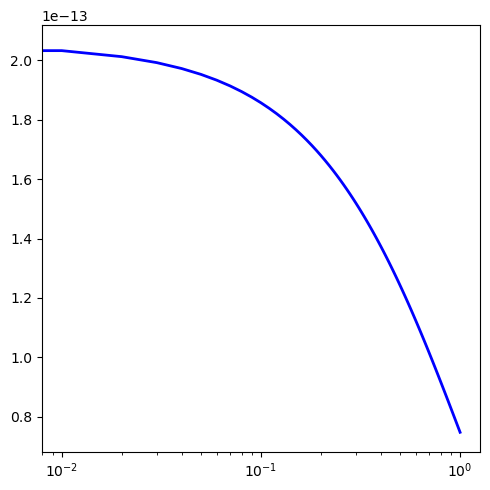

In [20]:
#Graphing

fig, axs = plt.subplots(figsize=(5,5), sharex=True, tight_layout=True)

axs.semilogx(gamma_arr, G_flux_arr, '-', lw=2, color="blue", label="Net Flux for Cycle")
axs.semilogx(gamma_arr, G_const_arr, '--', lw=2, color="black", label="Net Flux for gamma=0.5")
axs.set_title("Net Cycle Flux per Pot. Dist.", fontsize=11)
axs.set_ylabel(r"Net Cycle Flux ($s^{-1}$)", fontsize=10)
axs.set_xlabel(r"Potential Distribution of State 2", fontsize=10)
axs.set_ylim(0, np.max(G_flux_arr)*1.1)
axs.set_xlim(0, 1)
axs.legend(bbox_to_anchor=(1, 1))
axs.grid(True)